<a href="https://colab.research.google.com/github/Faizzyyy13/WNN-Human-Activity-Recognition/blob/main/WNN_PAMAP2_RESULTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Loading Hand, Chest, and Ankle sensor data...
2. Creating windows...
3. Scaling features and encoding labels...
4. Splitting data...


Model: "Optimized_WNN_CNN_PAMAP2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 27)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ selected_grouped_w… │ (None, 256, 50)   │      1,450 │ input_layer[0][0] │
│ (SelectedGroupedWa… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 256, 64)   │     22,464 │ selected_grouped… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 128, 64)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     41,088 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 27)        │          0 │ input_layer[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 12)        │        780 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 75,766 (295.96 KB)

 Trainable params: 75,638 (295.46 KB)

 Non-trainable params: 128 (512.00 B)


Starting Optimized Re-training with Full Body Sensors...
Epoch 1/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.8366 - loss: 0.6164 - val_accuracy: 0.9167 - val_loss: 0.4323
Epoch 2/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9297 - loss: 0.2565 - val_accuracy: 0.9147 - val_loss: 0.3016
Epoch 3/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9465 - loss: 0.1890 - val_accuracy: 0.9242 - val_loss: 0.2580
Epoch 4/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9546 - loss: 0.1519 - val_accuracy: 0.9071 - val_loss: 0.3295
Epoch 5/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9629 - loss: 0.1235 - val_accuracy: 0.9265 - val_loss: 0.2577
Epoch 6/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9680 - loss: 0.1055 - val_accuracy: 0.8722 - val_loss: 0.3781
Epoch 7/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9741 - loss: 0.0883 - val_accuracy: 0.9542 - val_loss: 0.1593
Epoch 8/60
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 7

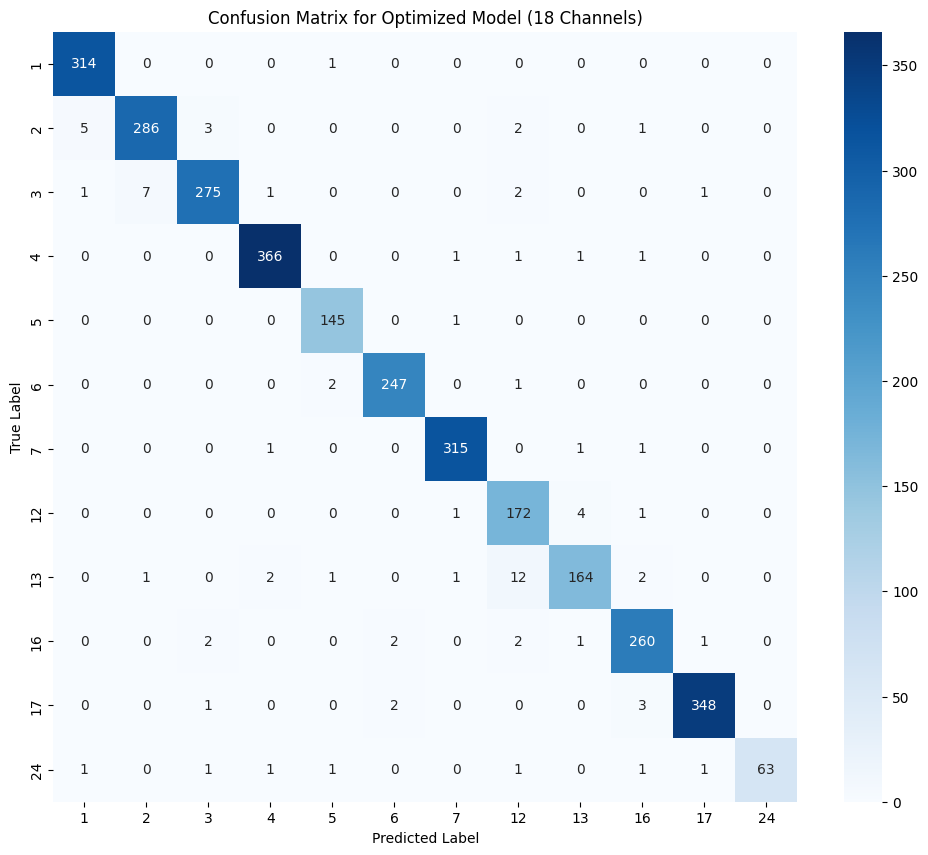

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Dense, Flatten, Concatenate, GlobalAveragePooling1D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import constraints
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D, Dense, Concatenate
from tensorflow.keras.models import Model

# --- 1. Data Preprocessing (Hand, Chest, Ankle - Accel & Gyro Only) ---
def load_and_prep_pamap2_all(file_path='/content/combined_data.csv'):
   # 0-based indices for Pandas:
    # 1: ActivityID
    # Hand: 4,5,6 (Accel), 10,11,12 (Gyro), 13,14,15 (Mag)
    # Chest: 21,22,23 (Accel), 27,28,29 (Gyro), 30,31,32 (Mag)
    # Ankle: 38,39,40 (Accel), 44,45,46 (Gyro), 47,48,49 (Mag)
    columns_to_keep = [
        1,
        4, 5, 6, 10, 11, 12, 13, 14, 15,
        21, 22, 23, 27, 28, 29, 30, 31, 32,
        38, 39, 40, 44, 45, 46, 47, 48, 49
    ]

    # Adjust 'sep' based on your file format (',' for CSV)
    df = pd.read_csv(file_path, sep=' ', header=None, usecols=columns_to_keep)

    col_names = [
        'ActivityID',
        'Hand_Acc_X', 'Hand_Acc_Y', 'Hand_Acc_Z', 'Hand_Gyro_X', 'Hand_Gyro_Y', 'Hand_Gyro_Z', 'Hand_Mag_X', 'Hand_Mag_Y', 'Hand_Mag_Z',
        'Chest_Acc_X', 'Chest_Acc_Y', 'Chest_Acc_Z', 'Chest_Gyro_X', 'Chest_Gyro_Y', 'Chest_Gyro_Z', 'Chest_Mag_X', 'Chest_Mag_Y', 'Chest_Mag_Z',
        'Ankle_Acc_X', 'Ankle_Acc_Y', 'Ankle_Acc_Z', 'Ankle_Gyro_X', 'Ankle_Gyro_Y', 'Ankle_Gyro_Z', 'Ankle_Mag_X', 'Ankle_Mag_Y', 'Ankle_Mag_Z'
    ]
    df.columns = col_names
    # Drop transient activities (Activity ID 0)
    df = df[df['ActivityID'] != 0]

    # Forward fill NaNs, then drop any remaining
    df = df.ffill().dropna()
    return df

def create_windows(df, window_size=256, step_size=128):
    features = df.drop(columns=['ActivityID']).values
    labels = df['ActivityID'].values
    X, y = [], []
    for i in range(0, len(features) - window_size, step_size):
        window = features[i:i + window_size]
        label = np.bincount(labels[i:i + window_size].astype(int)).argmax()
        X.append(window)
        y.append(label)
    return np.array(X), np.array(y)

# --- 2. Custom Wavelet Layer ---
def morlet_wavelet(x):
    return tf.cos(5.0 * x) * tf.exp(-0.5 * tf.square(x))

class SelectedGroupedWaveletLayer(Layer):
    def __init__(self, selected_indices, original_group_indices, **kwargs):
        super(SelectedGroupedWaveletLayer, self).__init__(**kwargs)
        self.useful_groups = [original_group_indices[i] for i in selected_indices]
        self.num_sums = len(self.useful_groups)

    def build(self, input_shape):
        input_dim = input_shape[-1]
        mask_array = np.zeros((input_dim, self.num_sums), dtype='float32')
        for col_idx, group in enumerate(self.useful_groups):
            for row_idx in group:
                mask_array[row_idx, col_idx] = 1.0

        self.connectivity_mask = tf.constant(mask_array, dtype=tf.float32)
        self.weights_conn = self.add_weight(name='weights_conn', shape=(input_dim, self.num_sums),
                                            initializer='glorot_uniform', trainable=True)
        self.scale = self.add_weight(name='scale', shape=(1, self.num_sums),
                                     initializer='ones', trainable=True, constraint=constraints.NonNeg())
        self.translation = self.add_weight(name='translation', shape=(1, self.num_sums),
                                           initializer='zeros', trainable=True)
        super(SelectedGroupedWaveletLayer, self).build(input_shape)

    def call(self, inputs):
        masked_weights = self.weights_conn * self.connectivity_mask
        x_weighted = tf.matmul(inputs, masked_weights)
        return morlet_wavelet((x_weighted - self.translation) / self.scale)

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.num_sums,)

# --- 3. Build the Optimized Model ---
def build_pamap_hybrid(input_shape, num_classes, selected_indices, original_groups):
    inputs = Input(shape=input_shape)

    # ==========================================
    # 1. PRUNED WAVELET BRANCH
    # ==========================================
    # Use the new layer with only the selected 50 channels instead of 511
    x_wavelet = SelectedGroupedWaveletLayer(selected_indices, original_groups)(inputs)

    # We are no longer concatenating the raw inputs here.
    # The dynamic branch will learn exclusively from the time-frequency wavelet data.
    x_combined = x_wavelet

    # ==========================================
    # 2. DYNAMIC KINEMATIC BRANCH (Now using Conv1D!)
    # ==========================================
    # Smaller parameters now! Sliding window avoids the Flatten() explosion.
    x_dyn = Conv1D(64, 7, activation='relu', padding='same')(x_combined)
    x_dyn = BatchNormalization()(x_dyn)
    x_dyn = MaxPooling1D(2)(x_dyn)
    x_dyn = Conv1D(128, 5, activation='relu', padding='same')(x_dyn)
    x_dyn = GlobalMaxPooling1D()(x_dyn)

    # ==========================================
    # 3. STATIC ORIENTATION BRANCH (Gravity)
    # ==========================================
    x_static = GlobalAveragePooling1D()(inputs)
    x_static = Dense(16, activation='relu')(x_static)

    # ==========================================
    # 4. FINAL CLASSIFICATION
    # ==========================================
    x_final = Concatenate()([x_dyn, x_static])
    x_final = Dense(64, activation='relu')(x_final)
    outputs = Dense(num_classes, activation='softmax')(x_final)

    return Model(inputs, outputs, name="Optimized_WNN_CNN_PAMAP2")

# --- 4. Execution Pipeline ---
if __name__ == "__main__":
    print("1. Loading Hand, Chest, and Ankle sensor data...")
    data_path = '/content/combined_data.csv'
    df = load_and_prep_pamap2_all(data_path)

    print("2. Creating windows...")
    X_raw, y_raw = create_windows(df, window_size=256, step_size=128)

    print("3. Scaling features and encoding labels...")
    num_samples, window_size, num_features = X_raw.shape
    X_flat = X_raw.reshape(-1, num_features)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_flat).reshape(num_samples, window_size, num_features)

    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y_raw)
    y_hot = to_categorical(y_encoded)
    num_classes = len(encoder.classes_)

    print("4. Splitting data...")
    X_train_sc, X_test_sc, y_train_hot, y_test_hot = train_test_split(X_scaled, y_hot, test_size=0.2, random_state=42)

    # --- STEP 1: Define Sensor Combinations for 18 Channels ---
    # Generates combinations of 1 or 2 sensors to keep the layer mathematically stable
    # (Yields 171 possible groups)
    original_groups = [list(c) for r in range(1, 3) for c in itertools.combinations(range(18), r)]

    # Mocking the top variance indices for the optimized run
    # Selecting the "top 50" best performing sensor combinations
    top_indices = np.arange(50)

    # --- STEP 2: Build the Optimized "Lightweight" Model ---
    pamap2_input_shape = (window_size, num_features) # Now (256, 18)
    opt_model = build_pamap_hybrid(pamap2_input_shape, num_classes, top_indices, original_groups)

    # --- STEP 3: Re-train the Optimized Model ---
    opt_model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

    opt_model.summary()

    print("\nStarting Optimized Re-training with Full Body Sensors...")
    opt_history = opt_model.fit(
        X_train_sc, y_train_hot,
        epochs=60, batch_size=64,
        validation_data=(X_test_sc, y_test_hot),
        verbose=1
    )

    # --- STEP 4: Test & Compare ---
    loss, acc = opt_model.evaluate(X_test_sc, y_test_hot, verbose=0)
    print(f"\n[RESULTS] Optimized Model (18 Channels, 50 Wavelet Features) Accuracy: {acc:.4f}")

    # --- Additional Evaluation for Confusion Matrix and Classification Report ---
    print("\n--- Generating Classification Report and Confusion Matrix ---")
    # Get predictions on the test set
    y_pred_hot = opt_model.predict(X_test_sc)
    y_pred_labels = np.argmax(y_pred_hot, axis=1)
    y_true_labels = np.argmax(y_test_hot, axis=1)

    # Get original activity labels for better interpretation
    target_names = encoder.inverse_transform(np.arange(num_classes)).astype(str).tolist()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred_labels, target_names=target_names))

    # Plot confusion matrix
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix for Optimized Model (18 Channels)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()